<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/LRFM_analysis_eng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to LRFM analysis**
---

In the realm of data-driven marketing and analytics, businesses are constantly seeking ways to understand and leverage customer behavior to drive growth and profitability. One powerful tool in this endeavor is length, recency, frequency, and monetary (LRFM) analysis.

RFM analysis focuses on customer segmentation based on loyalty, recent purchase activity, transaction frequency, and monetary value.

By understanding the behavior of customer groups through customer segmentation based on length, recency, frequency, and monetary value, this analytical technique will play a crucial role in driving marketing success in today's highly competitive era.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## **1. What is LRFM Analysis?**
LRFM Analysis is a customer segmentation technique similar to RFM (Recency, Frequency, Monetary), but with the addition of a new dimension: Length. LRFM stands for:

* L (Length): Measures the duration or length of the relationship between a customer and a company, usually calculated as the difference between the first and last purchase dates. This indicator indicates a customer's long-term loyalty or fidelity to a brand or product.

* R (Recency): Measures how recent or recent a customer's last transaction was. The lower the value, the more recent the transaction, indicating that the customer is still active.

* F (Frequency): Measures how often a customer makes transactions within a given time period. Customers who make frequent transactions tend to be more loyal.

* M (Monetary): Measures the total value or amount of money spent by a customer over a given time period. The higher the value, the more valuable the customer is to the company.

## **2. Why is it valuable?**

There are several advantages of using LRFM analysis, including:

* Customer Segmentation: Grouping customers based on their behavior, making it easier to tailor marketing strategies and product offerings.

* Increased Loyalty: By adding the Length dimension, companies can focus more on customers with long-term relationships, which can aid in developing loyalty programs.

* Customer Retention: Identifying customers at risk of not returning and developing more effective retention strategies.

## **3. LRFM Analysis with Python**
Next, we'll demonstrate how to perform an LRFM analysis in Python.

In [2]:
lrfm_analysis_csv = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRU1DjTLXx_eytmjZRR4uX2EHeq-7va4dGw9me6YR2E-iMilH254FM6bvm-3x_DLwBPd9bHXjk0B7QP/pub?gid=1851125177&single=true&output=csv'

df = pd.read_csv(
    lrfm_analysis_csv,
    parse_dates=['InvoiceDate'], # converts the InvoiceDate column to datetime
    dtype={'CustomerID':str} # converts the CustomerID column to a string
)
df.sample(10, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
47403,545819,21175,GIN + TONIC DIET METAL SIGN,2,2011-07-03 12:31:00,2.55,16356,United Kingdom
336821,577479,23265,SET OF 3 WOODEN TREE DECORATIONS,12,2011-11-20 11:34:00,1.25,14911,EIRE
307418,574720,72232,FENG SHUI PILLAR CANDLE,12,2011-06-11 14:39:00,0.19,14547,United Kingdom
376215,581169,22804,PINK HANGING HEART T-LIGHT HOLDER,6,2011-07-12 14:54:00,2.95,16779,United Kingdom
160692,559934,21903,MAN FLU METAL SIGN,12,2011-07-14 09:58:00,2.10,13012,United Kingdom
135725,556814,23133,LARGE IVORY HEART WALL ORGANISER,2,2011-06-15 08:34:00,8.25,14852,United Kingdom
150952,558750,23208,LUNCH BAG VINTAGE LEAF DESIGN,20,2011-03-07 10:47:00,1.65,18226,United Kingdom
361562,579712,23215,JINGLE BELL HEART ANTIQUE SILVER,4,2011-11-30 14:17:00,2.08,15467,United Kingdom
4896,540524,22082,RIBBON REEL STRIPES DESIGN,5,2011-09-01 12:53:00,1.65,16735,United Kingdom
377654,581376,22633,HAND WARMER UNION JACK,6,2011-08-12 12:43:00,2.10,14719,United Kingdom


In [3]:
# data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379979 entries, 0 to 379978
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    379979 non-null  object        
 1   StockCode    379979 non-null  object        
 2   Description  379979 non-null  object        
 3   Quantity     379979 non-null  int64         
 4   InvoiceDate  379979 non-null  datetime64[ns]
 5   UnitPrice    379979 non-null  float64       
 6   CustomerID   379979 non-null  object        
 7   Country      379979 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 23.2+ MB


Note that we use parse_dates to convert InvoiceDate from an object to a datetime. We also use dtype to convert CustomerID from an integer to an object.

Next, we'll create an LRFM analysis in several steps.

### 1. Calculate LRFM values
Now let's calculate the length, recency, frequency, and monetary values.

### Length & Recency

As explained in the previous section, length measures the duration of the relationship between a customer and a company, while recency measures how long it took the customer to complete their last transaction. Therefore, to obtain length and recency values, you first need to know the customer's last transaction date. Assuming the analysis day is calculated from the last transaction day + 1.

In [4]:
# Length & Recency
import datetime

analysis_date = df['InvoiceDate'].max() + datetime.timedelta(1)
analysis_date

Timestamp('2011-12-11 17:19:00')

The next step is to calculate the length and recency of each customer.

In [5]:
df_length_recency = df.groupby('CustomerID').agg(
length=('InvoiceDate', lambda x: (analysis_date - x.min()).days), # From the first time the user registered/used the account until this analysis was performed (in days)
recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days), # From the last time the user used the account until this analysis was performed (in days)
)

df_length_recency.sample(5, random_state=42)

,length,recency
CustomerID,,
15110,320,25
17655,286,12
18200,107,107
12573,229,229
15797,321,97


The table above shows that customer ID 15797 joined 321 days ago, while customer ID 18200 joined only 107 days ago. Recency-wise, customer ID 12573 last shopped 229 days ago. This means that customer ID 12573 hasn't shopped at the store in quite some time. Customer ID 17655 made her last transaction only 12 days ago, meaning she's relatively new to shopping at the store.

#### Frequency
To determine how frequently customers make transactions, we can analyze each customer's spending frequency.

In [6]:
df_frequency = df.groupby('CustomerID').agg(
    frequency=('InvoiceNo', lambda x: x.nunique())
)

df_frequency.sample(5, random_state=42)

,frequency
CustomerID,
15110,7
17655,6
18200,1
12573,1
15797,4


We know that Customer 12573 has been with this store for quite some time, but judging by their frequency, they've only made one purchase, making them very low-frequency. This contrasts with Customer 17655, who makes more frequent purchases, as evidenced by the six transactions she has made with this store.

#### Monetary

Next, monetary measures how much a customer spends on each transaction. The monetary value can be calculated by multiplying the price of the item purchased by the number of items purchased in a single transaction. To do this, we will first create a TotalPrice column, which displays the result of multiplying the UnitPrice by the Quantity.

In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
47403,545819,21175,GIN + TONIC DIET METAL SIGN,2,2011-07-03 12:31:00,2.55,16356,United Kingdom,5.10
336821,577479,23265,SET OF 3 WOODEN TREE DECORATIONS,12,2011-11-20 11:34:00,1.25,14911,EIRE,15.00
307418,574720,72232,FENG SHUI PILLAR CANDLE,12,2011-06-11 14:39:00,0.19,14547,United Kingdom,2.28
376215,581169,22804,PINK HANGING HEART T-LIGHT HOLDER,6,2011-07-12 14:54:00,2.95,16779,United Kingdom,17.70
160692,559934,21903,MAN FLU METAL SIGN,12,2011-07-14 09:58:00,2.10,13012,United Kingdom,25.20


The next step is to add up the TotalPrice of each customer.

In [8]:
df_monetary = df.groupby('CustomerID').agg(
    monetary=('TotalPrice', 'sum'),
)

df_monetary.sample(5, random_state=42)

,monetary
CustomerID,
15110,970.25
17655,1962.84
18200,163.80
12573,160.54
15797,2207.40


Returning to customer 12573, this customer has only made one transaction and hasn't made another in a long time. Furthermore, the transaction value was relatively small, at USD 160.54. Meanwhile, customer 17655 had a total expenditure of USD 1962.84 across six transactions.

Next, all the information obtained—length, recency, frequency, and monetary—will be combined into a single data frame to facilitate customer segmentation analysis.

In [9]:
df_customer = df.groupby('CustomerID').agg(
    length=('InvoiceDate', lambda x: (analysis_date - x.min()).days),
    recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    frequency=('InvoiceNo', lambda x: x.nunique()),
    monetary=('TotalPrice', 'sum'),
)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary
CustomerID,,,,
15110,320,25,7,970.25
17655,286,12,6,1962.84
18200,107,107,1,163.80
12573,229,229,1,160.54
15797,321,97,4,2207.40


The following is an explanation of each of the variables above:

| Variable | Description |
| --- | --- |
| customerID | Customer ID|
| length | Customer age, obtained from the difference between the first day of the transaction and the day of analysis |
| recency | The difference between the last day of the transaction and the day of analysis |
| frequency | Number of transactions made by the customer |
| monetary | Amount spent by the customer |

### 2. Assigning Scores
Next, we will determine the scores using the following methods:

* Rule-Based: Frequency
* Statistical Approach: Length, Recency, and Monetary

**Length Segmentation**

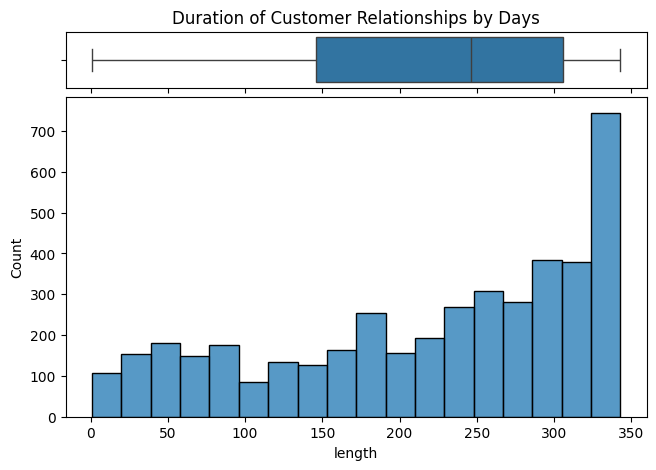

,length
0.00,1.0
0.25,146.0
0.50,246.0
0.75,306.0
1.00,343.0


In [10]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2,
                            ncols=1,
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='length', ax=ax_top)
sns.histplot(data=df_customer, x='length', ax=ax_bot)

ax_top.set(
    title='Duration of Customer Relationships by Days'
)

plt.show()
display(df_customer['length'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers based on their length into four groups:

* 4 (Veteran): Have joined for more than 306 days
* 3 (Established): Have joined between 246 and 306 days
* 2 (Acquainted): Have joined between 146 and 246 days
* 1 (Newcomer): Have joined between 1 and 146 days

In [11]:
df_customer['l_score'] = pd.qcut(
  df_customer['length'],          # data
  q=4,                            # divided into 4 equal groups
  labels=[1, 2, 3, 4]             # labeling, for length: the longer the length, the higher the score
).astype(int)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score
CustomerID,,,,,
15110,320,25,7,970.25,4
17655,286,12,6,1962.84,3
18200,107,107,1,163.80,1
12573,229,229,1,160.54,2
15797,321,97,4,2207.40,4


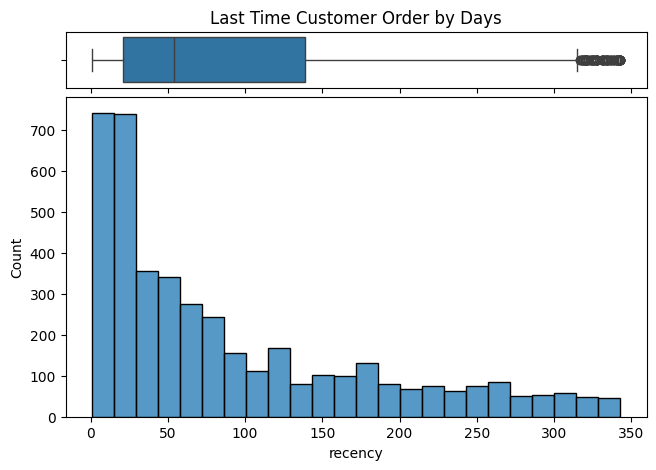

,recency
0.00,1.0
0.25,21.0
0.50,54.0
0.75,139.0
1.00,343.0


In [12]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2,
                            ncols=1,
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='recency', ax=ax_top)
sns.histplot(data=df_customer, x='recency', ax=ax_bot)

ax_top.set(
    title='Last Time Customer Order by Days'
)

plt.show()
display(df_customer['recency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers based on their recency into four groups:

* 4 (Active): Transactions made in less than 21 days
* 3 (Warm): Transactions made between 21 and 54 days
* 2 (Cold): Transactions made between 54 and 139 days
* 1 (Inactive): Transactions made more than 139 days

In [13]:
df_customer['r_score'] = pd.qcut(
  df_customer['recency'],           # data
  q=4,                              # divided into 4 equal groups
  labels=[4, 3, 2, 1]               # labeling, for recency: the lower the score, the higher the score
).astype(int)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score
CustomerID,,,,,,
15110,320,25,7,970.25,4,3
17655,286,12,6,1962.84,3,4
18200,107,107,1,163.80,1,2
12573,229,229,1,160.54,2,1
15797,321,97,4,2207.40,4,2


**Frequency Segmentation**

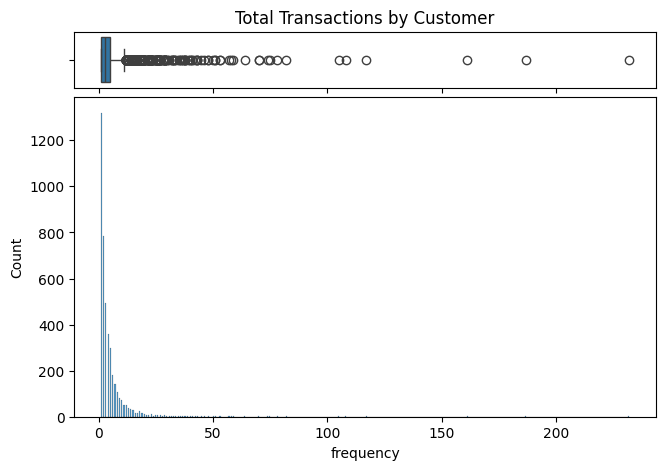

,frequency
0.00,1.0
0.25,1.0
0.50,3.0
0.75,5.0
1.00,232.0


In [14]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2,
                            ncols=1,
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='frequency', ax=ax_top)
sns.histplot(data=df_customer, x='frequency', ax=ax_bot)

ax_top.set(
    title='Total Transactions by Customer'
)

plt.show()
display(df_customer['frequency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers into four groups based on their frequency, based on the number of transactions we have determined:

* 4 (Loyal): Makes more than 5 transactions
* 3 (High): Makes 4 to 5 transactions
* 2 (Medium): Makes 2 to 3 transactions
* 1 (Low): Makes only 1 transaction.

In [15]:
def f_score(x):
    if x==1:
        return 1
    elif x <= 3:
        return 2
    elif x <= 5:
        return 3
    else:
        return 4

df_customer['f_score'] = df_customer['frequency'].apply(f_score)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score
CustomerID,,,,,,,
15110,320,25,7,970.25,4,3,4
17655,286,12,6,1962.84,3,4,4
18200,107,107,1,163.80,1,2,1
12573,229,229,1,160.54,2,1,1
15797,321,97,4,2207.40,4,2,3


**Monetary Segmentation**

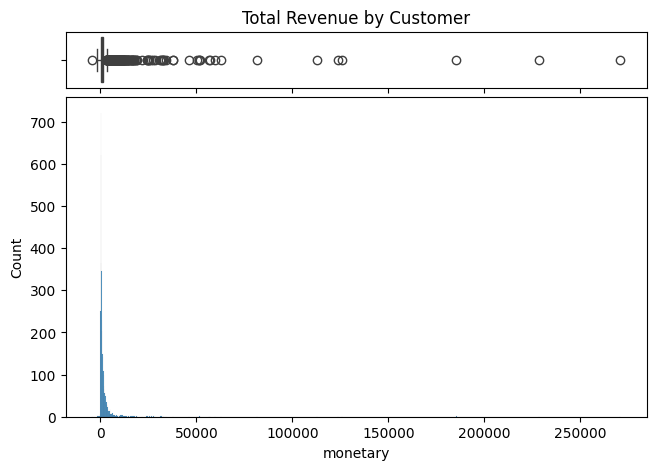

,monetary
0.00,-4287.630
0.25,290.955
0.50,642.485
0.75,1563.750
1.00,270897.140


In [16]:
fig, (ax_top, ax_bot) = plt.subplots(
                            nrows=2,
                            ncols=1,
                            figsize=(7.5, 5),
                            gridspec_kw={
                                'height_ratios': (0.15, 0.85),
                                'hspace': 0.05
                            }
                        )

sns.boxplot(data=df_customer, x='monetary', ax=ax_top)
sns.histplot(data=df_customer, x='monetary', ax=ax_bot)

ax_top.set(
    title='Total Revenue by Customer'
)

plt.show()
display(df_customer['monetary'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers into four groups based on their monetary value:

* 4 (Top Spender): Transactions exceeding USD 1,563.75
* 3 (High Spender): Transactions between USD 642.48 and USD 1,563.75
* 2 (Medium Spender): Transactions between USD 290.95 and USD 642.48
* 1 (Low Spender): Transactions less than USD 290.95

In [17]:
df_customer['m_score'] = pd.qcut(
    df_customer['monetary'],      # data
    q=4,                          # divided into 4 equal groups
    labels=[1, 2, 3, 4]           # labeling, for monetary: the larger the value, the higher the score
).astype(int)

df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score
CustomerID,,,,,,,,
15110,320,25,7,970.25,4,3,4,3
17655,286,12,6,1962.84,3,4,4,4
18200,107,107,1,163.80,1,2,1,1
12573,229,229,1,160.54,2,1,1,1
15797,321,97,4,2207.40,4,2,3,4


### 3. Segment Labeling
Next, we will perform customer segmentation in several different ways:

* Total Score Approach
* Combining Individual Scores Approach
* K-Means Clustering

a. Total Score Approach

In this step, we will add the l_score, r_score, f_score, and m_score to get the rfm_score_total.

In [18]:
df_customer['lrfm_score_total'] = df_customer['l_score'] + df_customer['r_score'] + df_customer['f_score'] + df_customer['m_score']
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_total
CustomerID,,,,,,,,,
15110,320,25,7,970.25,4,3,4,3,14
17655,286,12,6,1962.84,3,4,4,4,15
18200,107,107,1,163.80,1,2,1,1,5
12573,229,229,1,160.54,2,1,1,1,5
15797,321,97,4,2207.40,4,2,3,4,13


Then we will group it into 4 segments with the following provisions:

In [19]:
def segmentation_by_total(x):
    if x <= 7:
        return 'Bronze'
    elif x <= 11:
        return 'Silver'
    elif x <= 13:
        return 'Gold'
    else:
        return 'Platinum'

df_customer['lrfm_segment_total'] = df_customer['lrfm_score_total'].apply(segmentation_by_total)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_total,lrfm_segment_total
CustomerID,,,,,,,,,,
15110,320,25,7,970.25,4,3,4,3,14,Platinum
17655,286,12,6,1962.84,3,4,4,4,15,Platinum
18200,107,107,1,163.80,1,2,1,1,5,Bronze
12573,229,229,1,160.54,2,1,1,1,5,Bronze
15797,321,97,4,2207.40,4,2,3,4,13,Gold


We will try to display the characteristics of each segment in the form of a visualization as follows:

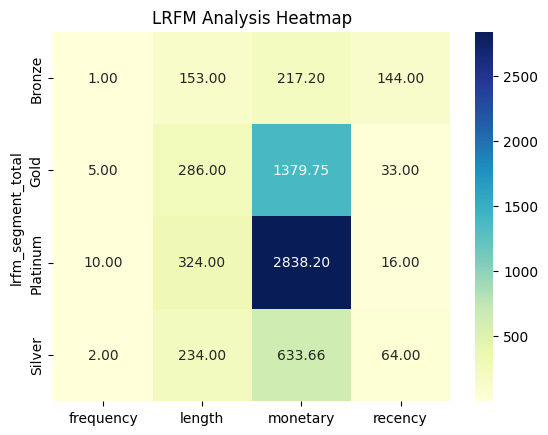

In [20]:
lrfm_heatmap = df_customer.pivot_table(index='lrfm_segment_total', values=['length', 'recency', 'frequency', 'monetary'], aggfunc='median')

# Create the heatmap
sns.heatmap(lrfm_heatmap, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('LRFM Analysis Heatmap')
plt.show()

Based on the divided segments, we can characterize them as below:

**Segment Insights**

**1. Bronze**

* Very low frequency (≈1 order per customer)

* Short customer lifespan (Length ≈ 153 days)

* Low monetary value (~217)

* High recency (144 days since last purchase → inactive)

* **Characteristics:** One-time/irregular customers, long inactive period, low value.

**2. Silver**

* Low frequency (≈2 orders)

* Medium length (≈234 days active)

* Moderate monetary (~634)

* Recency better than Bronze (~64 days)
* **Characteristics:** Occasional customers, moderate spenders, some are still active.

**3. Gold**

* Moderate frequency (≈5 orders)

* Long length (≈286 days active)

* High monetary (~1,380)

* Low recency (33 days) → relatively recent activity
* **Characteristics:** Valuable customers, fairly engaged, consistent buyers.

**4. Platinum**

* Highest frequency (≈10 orders)

* Longest customer lifespan (≈324 days)

* Very high monetary (~2,838)

* Very low recency (16 days) → very recent activity
* **Characteristics:** Most loyal and profitable customers, frequent buyers, highly engaged.


**Summary**

* Bronze = Dormant/one-time

* Silver = Low-value, occasional

* Gold = Engaged, high-value

* Platinum = Loyal champions, top spenders

In [21]:
import plotly.express as px

color_map = {'Bronze' : 'brown', 'Silver' : 'gray', 'Gold' : 'orange', 'Platinum' : 'red'}

fig = px.scatter_3d(
    df_customer,
    x='recency',
    y='frequency',
    z='monetary',
    color='lrfm_segment_total',
    color_discrete_map=color_map,
)

fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "RFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                    legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")


**b. Combining Individual Scores Approach**

In this stage we will combine l_score, r_score, f_score, and m_score into lrfm_score_combined

In [22]:
df_customer['lrfm_score_combined'] = df_customer['l_score'].astype(str) + df_customer['r_score'].astype(str) + df_customer['f_score'].astype(str) + df_customer['m_score'].astype(str)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_total,lrfm_segment_total,lrfm_score_combined
CustomerID,,,,,,,,,,,
15110,320,25,7,970.25,4,3,4,3,14,Platinum,4343
17655,286,12,6,1962.84,3,4,4,4,15,Platinum,3444
18200,107,107,1,163.80,1,2,1,1,5,Bronze,1211
12573,229,229,1,160.54,2,1,1,1,5,Bronze,2111
15797,321,97,4,2207.40,4,2,3,4,13,Gold,4234


Then we will group it into 4 segments with the following provisions:

In [23]:
seg_map = {
    r'[1-2][1-4][1-4][1-2]': 'New Cust Low Value',
    r'[1-2][1-4][1-4][3-4]': 'New Cust High Value',
    r'[3-4][1-2][1-2][1-2]': 'Old Cust Inactive',
    r'[3-4][1-2][1-4][1-4]': 'At Risk',
    r'[3-4][1-2][3-4][3-4]': 'Need Attention',
    r'[3-4][3-4][3-4][3-4]': 'Loyal Cust',
    r'[3-4][3-4][3-4][1-2]': 'Potensial Loyal Cust',
    r'[3-4][3-4][1-2][1-4]': 'Reactivated Old Cust'
}

df_customer['lrfm_segment_combined'] = df_customer['lrfm_score_combined'].replace(seg_map, regex=True)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_total,lrfm_segment_total,lrfm_score_combined,lrfm_segment_combined
CustomerID,,,,,,,,,,,,
15110,320,25,7,970.25,4,3,4,3,14,Platinum,4343,Loyal Cust
17655,286,12,6,1962.84,3,4,4,4,15,Platinum,3444,Loyal Cust
18200,107,107,1,163.80,1,2,1,1,5,Bronze,1211,New Cust Low Value
12573,229,229,1,160.54,2,1,1,1,5,Bronze,2111,New Cust Low Value
15797,321,97,4,2207.40,4,2,3,4,13,Gold,4234,At Risk


We will try to display the characteristics of each segment in the form of a visualization as follows:

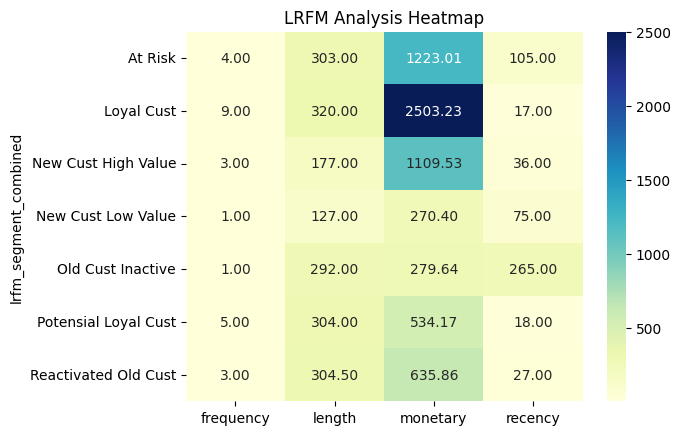

In [24]:
lrfm_heatmap = df_customer.pivot_table(index='lrfm_segment_combined', values=['length', 'recency', 'frequency', 'monetary'], aggfunc='median')

# Create the heatmap
sns.heatmap(lrfm_heatmap, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('LRFM Analysis Heatmap')
plt.show()

Now, we can provide more detailed segmentation process than the first one.

**Segment Insights**

**1. At Risk**

* Frequency: ~4

* Length: ~303 days (long relationship)

* Monetary: ~1,223 (mid-high)

* Recency: ~105 days (long inactivity)
* **Insights**:  Previously good customers but now disengaged; at risk of churn.

**2. Loyal Customers**

* Frequency: ~9 (highest)

* Length: ~320 days (longest)

* Monetary: ~2,503 (very high)

* Recency: ~17 days (very recent)
* **Insights**:  Top segment - highly engaged, frequent, loyal, and most profitable.

**3. New Customers – High Value**

* Frequency: ~3

* Length: ~177 days (relatively new)

* Monetary: ~1,110 (high for their short history)

* Recency: ~36 days (recently active)
* **Insights**: Promising newcomers - strong spending despite being relatively new.

4. New Customers – Low Value

* Frequency: ~1

* Length: ~127 days (shortest)

* Monetary: ~270 (low)

* Recency: ~75 days (inactive for a while)
* **Insights**: One-time or low-value new customers with weak engagement.

5. Old Customers – Inactive

* Frequency: ~1

* Length: ~292 days (long history)

* Monetary: ~280 (low)

* Recency: ~265 days (very long inactivity)
* **Insights**: Long-term but inactive; likely churned with low contribution.

6. Potential Loyal Customers

* Frequency: ~5

* Length: ~304 days (long history)

* Monetary: ~534 (medium)

* Recency: ~18 days (recently active)
* **Insights**: Engaged segment with potential to upgrade into loyal customers.

7. Reactivated Old Customers

* Frequency: ~3

* Length: ~305 days (long history)

* Monetary: ~636 (moderate)

* Recency: ~27 days (recently active again)
* **Insights**: Customers who returned after inactivity; show signs of recovery.

**To sum up**

* Loyal Cust = core champions

* At Risk & Old Cust Inactive = need win-back strategies

* New Cust High Value = nurture to become loyal

* New Cust Low Value = test low-cost engagement

* Potential Loyal Cust & Reactivated Old Cust = opportunity to strengthen relationship

In [25]:
# Visualization with plotly
import plotly.express as px

color_map = {
    'Loyal Cust' : 'gray',
    'Potensial Loyal Cust' : 'purple',
    'New Cust High Value' : 'pink',
    'New Cust Low Value' : 'blue',
    'Need Attention' : 'green',
    'At Risk' : 'yellow',
    'Reactivated Old Cust' : 'orange',
    'Old Cust Inactive' : 'red',
}

fig = px.scatter_3d(
    df_customer,
    x='recency',
    y='frequency',
    z='monetary',
    color='lrfm_segment_combined',
    color_discrete_map=color_map,
)

fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "RFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                    legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")

**c. K-Means Clustering**

In this step, we'll let the model find patterns from the l_score, r_score, f_score, and m_score values. In this case, we'll try to divide the segments into three clusters.

In [26]:
# Import required libraries
from sklearn.cluster import KMeans

# Define a KMeans model with 3 clusters
model = KMeans(n_clusters=3, random_state=42)

# Fitting the model
model.fit(df_customer.loc[:, 'length':'monetary'])

# Add labels
df_customer['lrfm_segment_clustering'] = model.labels_.astype(str)
df_customer.sample(5, random_state=42)

,length,recency,frequency,monetary,l_score,r_score,f_score,m_score,lrfm_score_total,lrfm_segment_total,lrfm_score_combined,lrfm_segment_combined,lrfm_segment_clustering
CustomerID,,,,,,,,,,,,,
15110,320,25,7,970.25,4,3,4,3,14,Platinum,4343,Loyal Cust,0
17655,286,12,6,1962.84,3,4,4,4,15,Platinum,3444,Loyal Cust,0
18200,107,107,1,163.80,1,2,1,1,5,Bronze,1211,New Cust Low Value,0
12573,229,229,1,160.54,2,1,1,1,5,Bronze,2111,New Cust Low Value,0
15797,321,97,4,2207.40,4,2,3,4,13,Gold,4234,At Risk,0


We will try to display the characteristics of each segment in the form of a visualization as follows:

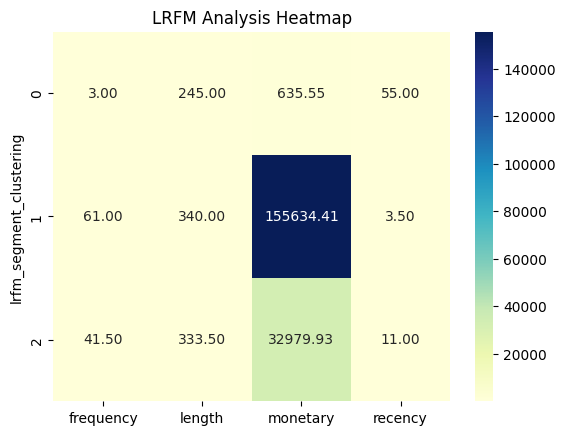

In [27]:
lrfm_heatmap = df_customer.pivot_table(index='lrfm_segment_clustering', values=['length', 'recency', 'frequency', 'monetary'], aggfunc='median')

# Create the heatmap
sns.heatmap(lrfm_heatmap, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('LRFM Analysis Heatmap')
plt.show()

**Segmentation/Cluster Insights**

**Cluster 0**

* Frequency: ~3 (very low)

* Length: ~245 days (shorter relationship)

* Monetary: ~636 (low spenders)

* Recency: ~55 days (not very recent)

* **Characteristics:** Low-value, occasional customers. Mostly inactive or one-time buyers with limited contribution.

**Cluster 1**

* Frequency: ~61 (very high)

* Length: ~340 days (longest relationship)

* Monetary: ~155,634 (extremely high!)

* Recency: ~3.5 days (very recent)
* **Characteristics:** Elite / VIP customers. Highly loyal, spend a lot, and actively engaged. Core segment driving revenue.

**Cluster 2**

* Frequency: ~42 (moderately high)

* Length: ~334 days (long history)

* Monetary: ~32,980 (high)

* Recency: ~11 days (recent)
* **Characteristics:** Strong and loyal customers. High frequency and high spending, but slightly below VIP level.

**Summary of 3 Clusters**

* Cluster 0 = Low-value, inactive customers

* Cluster 2 = Loyal high-value customers

* Cluster 1 = VIP elite customers (the backbone of business revenue)

In [28]:
import plotly.express as px

color_map = {
    '0' : 'red',
    '1' : 'green',
    '2' : 'blue',
}

fig = px.scatter_3d(
    df_customer,
    x='recency',
    y='frequency',
    z='monetary',
    color='lrfm_segment_clustering',
    color_discrete_map=color_map,
)

fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "RFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                    legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")

#**4. Comparison of Segmentation Approaches**

**1. Traditional LRFM (Bronze–Platinum)**

* Simple, intuitive, and easy to communicate.

* Focuses on broad categories (value & loyalty level).

* Good for a quick overview but may oversimplify customer diversity.

**2. Detailed LRFM (7 Segments)**

* More nuanced: separates new, old, reactivated, loyal, at-risk.

* Allows targeted strategies per customer lifecycle stage.

* Strong for marketing action planning.

**3. K-Means LRFM Clustering (3 Clusters)**

* Data-driven, less subjective.

* Clear separation into low, high, and VIP customers.

* Captures spending power (monetary differences) more sharply.

* But less interpretable in terms of lifecycle (no direct "new/old" labels).

**Summary table**

| Method                                                | Segments & Labels                                                                                                                                                                                                    | Key Characteristics                                         | Strengths                                                                 | Limitations                                                                |
| ----------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------- | ------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Traditional LRFM** (Bronze, Silver, Gold, Platinum) | Bronze = dormant/one-time<br>Silver = low-value occasional<br>Gold = engaged, high-value<br>Platinum = loyal champions                                                                                               | Broad levels of engagement & spending                       | Simple, easy to explain, quick insight                                    | Too coarse, hides customer lifecycle differences                           |
| **Detailed LRFM** (7 segments)                        | Loyal Cust = core champions<br>At Risk & Old Cust Inactive = need win-back<br>New Cust High Value = nurture to loyal<br>New Cust Low Value = test engagement<br>Potential Loyal & Reactivated = growth opportunities | Covers customer lifecycle: new, at risk, reactivated, loyal | Very actionable, supports tailored marketing strategies                   | More complex to maintain, some overlaps between groups                     |
| **K-Means Clustering** (3 clusters)                   | Cluster 0 = low-value inactive<br>Cluster 2 = loyal high-value<br>Cluster 1 = VIP elite                                                                                                                              | Focused on spending, frequency, and activity                | Data-driven, sharp monetary separation, useful for revenue prioritization | Less interpretability (no "new/old" labels), fewer behavioral distinctions |


Those three strategies posses few advantages and disadvantages. However, we can select which model that may fit based on consideration such as
*  Use Traditional LRFM for a high-level overview.
* Use Detailed LRFM for marketing strategy & lifecycle management.
* Use K-Means for data-driven prioritization of revenue contribution.